# Figure S11

Maps long-term and drought-season net-infiltration totals.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from pyproj import Transformer
import rasterio
import torch


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / '10 precipitation').exists():
            return candidate
    raise RuntimeError('Could not locate repository root.')


ROOT = find_repo_root()
DYNAMIC_PATH = ROOT / 'data' / 'train_val_test_inputs' / 'GNN_spacetime' / 'H6' / 'dynamic_monthly_cache.pt'
PRECIP_DIR = ROOT / 'data' / '10 precipitation' / 'daymet_prcp_monthly_v4r1_mrva'
PRECIP_MATRIX_PATH = PRECIP_DIR / 'daymet_prcp_monthly_mrva_1km.npy'
PRECIP_MONTH_PATH = PRECIP_DIR / 'month_index.csv'
GRID_PATH = PRECIP_DIR / 'grid_lookup.csv'
BOUNDARY_PATH = ROOT / 'data' / '0 mask MRVA' / 'outerboundary.shp'
RIVER_PATH = ROOT / 'data_raw' / '11 river_network' / 'HydroRIVERS_NorthAmerica' / 'HydroRIVERS_v10_na_shp' / 'HydroRIVERS_v10_na.shp'
SWB_MASK_PATH = ROOT / 'data' / '3 SWB net_infiltration' / 'swb_net_infiltration_2012_daily_1km_masked.tif'
OUT_DIR = ROOT / 'outputs' / 'figures' / 'FigS11'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_PATH = OUT_DIR / 'FigS11.png'

VARIABLE = 'Net infiltration'
DROUGHT_YEARS = (2012, 2022, 2023)
DROUGHT_MONTHS = (5, 10)

COLOR_MAPS = {
    'Precipitation': LinearSegmentedColormap.from_list(
        'precip', ['#F7FBFF', '#D8E9F2', '#92C0D4', '#397A99']
    ).with_extremes(bad='white'),
    'Net infiltration': LinearSegmentedColormap.from_list(
        'infiltration', ['#F7FCF5', '#D9EDDD', '#8BC4A8', '#2F806B']
    ).with_extremes(bad='white'),
    'Pumping': LinearSegmentedColormap.from_list(
        'pumping', ['#FFF9F2', '#F5DCC6', '#D99A69', '#9A4F2D']
    ).with_extremes(bad='white'),
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 0.8,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'axes.unicode_minus': False,
    'savefig.dpi': 600,
})


def display_path(path: Path) -> str:
    return str(path.resolve().relative_to(ROOT))


print('Variable:', VARIABLE)
print('Output:', display_path(OUT_DIR))

Variable: Net infiltration
Output: outputs\figures\FigS11


In [2]:
grid = pd.read_csv(GRID_PATH)

if VARIABLE == 'Precipitation':
    month_labels = pd.read_csv(PRECIP_MONTH_PATH)['month_label'].astype(str).to_numpy()
    precipitation = np.load(PRECIP_MATRIX_PATH, mmap_mode='r')
    if precipitation.shape != (len(month_labels), len(grid)):
        raise ValueError(f'Unexpected precipitation matrix shape: {precipitation.shape}')
    monthly_values = np.asarray(precipitation, dtype=np.float32).T
else:
    cache = torch.load(DYNAMIC_PATH, map_location='cpu', weights_only=False)
    month_labels = np.asarray(cache['month_labels']).astype(str)
    if not np.array_equal(cache['grid_ids'], grid['grid_id'].to_numpy()):
        raise ValueError('Dynamic forcing and grid IDs are not aligned.')
    feature_index = {name: index for index, name in enumerate(cache['feature_names'])}
    dynamic = np.asarray(cache['data'], dtype=np.float32)
    if VARIABLE == 'Net infiltration':
        monthly_values = dynamic[:, :, feature_index['monthly_sum_net_infiltration']]
    elif VARIABLE == 'Pumping':
        monthly_values = dynamic[:, :, feature_index['monthly_pumping']] / 1e6
    else:
        raise ValueError(f'Unsupported variable: {VARIABLE}')

month_year = np.array([int(label[:4]) for label in month_labels])
month_number = np.array([int(label[5:7]) for label in month_labels])
period_masks = [np.ones(len(month_labels), dtype=bool)]
period_masks.extend([
    (month_year == year)
    & (month_number >= DROUGHT_MONTHS[0])
    & (month_number <= DROUGHT_MONTHS[1])
    for year in DROUGHT_YEARS
])
if [int(mask.sum()) for mask in period_masks] != [156, 6, 6, 6]:
    raise ValueError('Unexpected month count in one or more plotting periods.')

period_values = [
    np.nansum(monthly_values[:, period_mask], axis=1)
    for period_mask in period_masks
]

if VARIABLE == 'Net infiltration':
    with rasterio.open(SWB_MASK_PATH) as source:
        swb_domain = source.read_masks(1) > 0
        swb_row = np.floor(
            (source.transform.f - grid['y_center']) / abs(source.transform.e)
        ).astype(int)
        swb_col = np.floor(
            (grid['x_center'] - source.transform.c) / source.transform.a
        ).astype(int)
        swb_valid = swb_domain[swb_row, swb_col]
    for values in period_values:
        values[~swb_valid] = np.nan

long_total = period_values[0]
drought_totals = np.concatenate(period_values[1:])
if VARIABLE == 'Precipitation':
    long_limits = (15000.0, np.nanpercentile(long_total, 98))
    drought_limits = (0.0, np.nanpercentile(drought_totals, 98))
else:
    long_limits = (0.0, np.nanpercentile(long_total, 99))
    drought_limits = (0.0, np.nanpercentile(drought_totals, 99))

long_norm = Normalize(*long_limits)
drought_norm = Normalize(*drought_limits)

print('Grid alignment verified:', len(grid), 'cells x', len(month_labels), 'months')
print('Drought window: May-October for 2012, 2022 and 2023')
print(f'Long scale: [{long_norm.vmin:.3g}, {long_norm.vmax:.3g}]')
print(f'Drought scale: [{drought_norm.vmin:.3g}, {drought_norm.vmax:.3g}]')

Grid alignment verified: 87871 cells x 156 months
Drought window: May-October for 2012, 2022 and 2023
Long scale: [0, 8.38e+03]
Drought scale: [0, 367]


In [3]:
n_rows = int(grid['row'].max()) + 1
n_cols = int(grid['col'].max()) + 1
row_index = grid['row'].to_numpy(dtype=int)
column_index = grid['col'].to_numpy(dtype=int)


def to_raster(cell_values: np.ndarray) -> np.ndarray:
    raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
    raster[row_index, column_index] = cell_values
    return raster


rasters = [to_raster(values) for values in period_values]

x_origin = float(np.median(grid['x_center'] - 1000.0 * column_index))
y_origin = float(np.median(grid['y_center'] - 1000.0 * row_index))
x_edges = x_origin - 500.0 + 1000.0 * np.arange(n_cols + 1)
y_edges = y_origin - 500.0 + 1000.0 * np.arange(n_rows + 1)
x_mesh, y_mesh = np.meshgrid(x_edges, y_edges)
transformer = Transformer.from_crs('EPSG:5070', 'EPSG:4326', always_xy=True)
lon_edges, lat_edges = transformer.transform(x_mesh, y_mesh)

boundary = gpd.read_file(BOUNDARY_PATH).to_crs('EPSG:4326')
rivers = gpd.read_file(RIVER_PATH, bbox=tuple(boundary.total_bounds))
rivers = rivers.loc[rivers['ORD_CLAS'].eq(1)].to_crs('EPSG:4326')
rivers = gpd.clip(rivers, boundary)

lon_min, lat_min, lon_max, lat_max = boundary.total_bounds
lon_padding = 0.025 * (lon_max - lon_min)
lat_padding = 0.015 * (lat_max - lat_min)
map_bounds = [
    lon_min - lon_padding,
    lon_max + lon_padding,
    lat_min - lat_padding,
    lat_max + lat_padding,
]
map_aspect = 1.0 / np.cos(np.deg2rad((lat_min + lat_max) / 2.0))

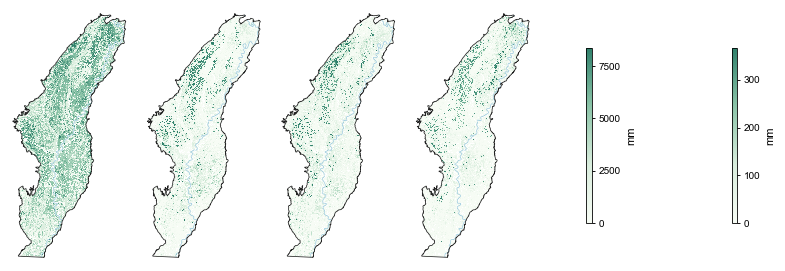

Saved: outputs\figures\FigS11\FigS11.png


In [4]:
figure = plt.figure(figsize=(8.8, 2.7), facecolor='white')
figure_left, figure_bottom, figure_top = 0.035, 0.035, 0.965
row_height = figure_top - figure_bottom
map_gap = 0.018
map_width = (
    row_height
    * (figure.get_figheight() / figure.get_figwidth())
    * (map_bounds[1] - map_bounds[0])
    / ((map_bounds[3] - map_bounds[2]) * map_aspect)
)
colorbar_x = [0.690, 0.855]
colorbar_width = 0.0065

for column in range(4):
    map_left = figure_left + column * (map_width + map_gap)
    axis = figure.add_axes([map_left, figure_bottom, map_width, row_height])
    norm = long_norm if column == 0 else drought_norm
    axis.pcolormesh(
        lon_edges,
        lat_edges,
        rasters[column],
        shading='flat',
        cmap=COLOR_MAPS[VARIABLE],
        norm=norm,
        rasterized=True,
    )
    rivers.plot(ax=axis, color='#79B8D0', linewidth=0.42, alpha=0.90, zorder=3)
    boundary.boundary.plot(ax=axis, color='#242424', linewidth=0.55, zorder=4)
    axis.set_xlim(map_bounds[0], map_bounds[1])
    axis.set_ylim(map_bounds[2], map_bounds[3])
    axis.set_aspect(map_aspect)
    axis.set_axis_off()

colorbar_bottom = figure_bottom + 0.15 * row_height
colorbar_height = 0.70 * row_height
total_colorbar_axis = figure.add_axes([
    colorbar_x[0], colorbar_bottom, colorbar_width, colorbar_height
])
drought_colorbar_axis = figure.add_axes([
    colorbar_x[1], colorbar_bottom, colorbar_width, colorbar_height
])
total_colorbar = figure.colorbar(
    mpl.cm.ScalarMappable(norm=long_norm, cmap=COLOR_MAPS[VARIABLE]),
    cax=total_colorbar_axis,
    orientation='vertical',
)
drought_colorbar = figure.colorbar(
    mpl.cm.ScalarMappable(norm=drought_norm, cmap=COLOR_MAPS[VARIABLE]),
    cax=drought_colorbar_axis,
    orientation='vertical',
)

unit = r'$10^6$ m$^3$' if VARIABLE == 'Pumping' else 'mm'
for colorbar in [total_colorbar, drought_colorbar]:
    colorbar.ax.yaxis.set_ticks_position('right')
    colorbar.ax.yaxis.set_label_position('right')
    colorbar.locator = MaxNLocator(nbins=4)
    colorbar.update_ticks()
    colorbar.ax.tick_params(labelsize=7.2, length=2.4, width=0.65, pad=2)
    colorbar.set_label(unit, fontsize=8.0, labelpad=4)
    colorbar.outline.set_linewidth(0.6)

figure.savefig(FIGURE_PATH, dpi=600, facecolor='white')
plt.show()

print('Saved:', display_path(FIGURE_PATH))